#### Section 4.1: Import Libraries and Load Data

In [102]:
import pandas as pd
import numpy as np
import os
import pickle
import heapq
from collections import defaultdict, deque
from sklearn.metrics.pairwise import cosine_similarity

# Load processed data
processed_path = r"D:\DevProjects\Python\AL2002-PROJECT\data\processed"

# Load category tree
cat_tree = pd.read_csv(os.path.join(processed_path, 'category_tree_clean.csv'))
print("Category tree shape:", cat_tree.shape)

# Load events (sampled, cleaned)
events = pd.read_csv(os.path.join(processed_path, 'events_clean.csv'))
events['datetime'] = pd.to_datetime(events['datetime'])

# Load Random Forest model and bandit (from Notebook 3)
with open(os.path.join(processed_path, 'random_forest_model.pkl'), 'rb') as f:
    rf = pickle.load(f)
with open(os.path.join(processed_path, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
with open(os.path.join(processed_path, 'kmeans_model.pkl'), 'rb') as f:
    kmeans = pickle.load(f)

# Load user clusters (sample)
user_clusters = pd.read_csv(os.path.join(processed_path, 'user_clusters_sample.csv'))

# Load KNN artifacts
from scipy.sparse import load_npz
item_user_sparse = load_npz(os.path.join(processed_path, 'item_user_sparse.npz'))
with open(os.path.join(processed_path, 'item_to_idx.pkl'), 'rb') as f:
    item_to_idx = pickle.load(f)
with open(os.path.join(processed_path, 'top_items_list.pkl'), 'rb') as f:
    top_items = pickle.load(f)
with open(os.path.join(processed_path, 'knn_model.pkl'), 'rb') as f:
    knn = pickle.load(f)

print("All data loaded.")

Category tree shape: (1669, 2)
All data loaded.


#### Section 4.2: Build Category Graph

Root categories (first 10): [231, 791, 1490, 431, 755, 378, 1579, 1394, 659, 1057]
Total nodes: 1668
Number of connected components: 24


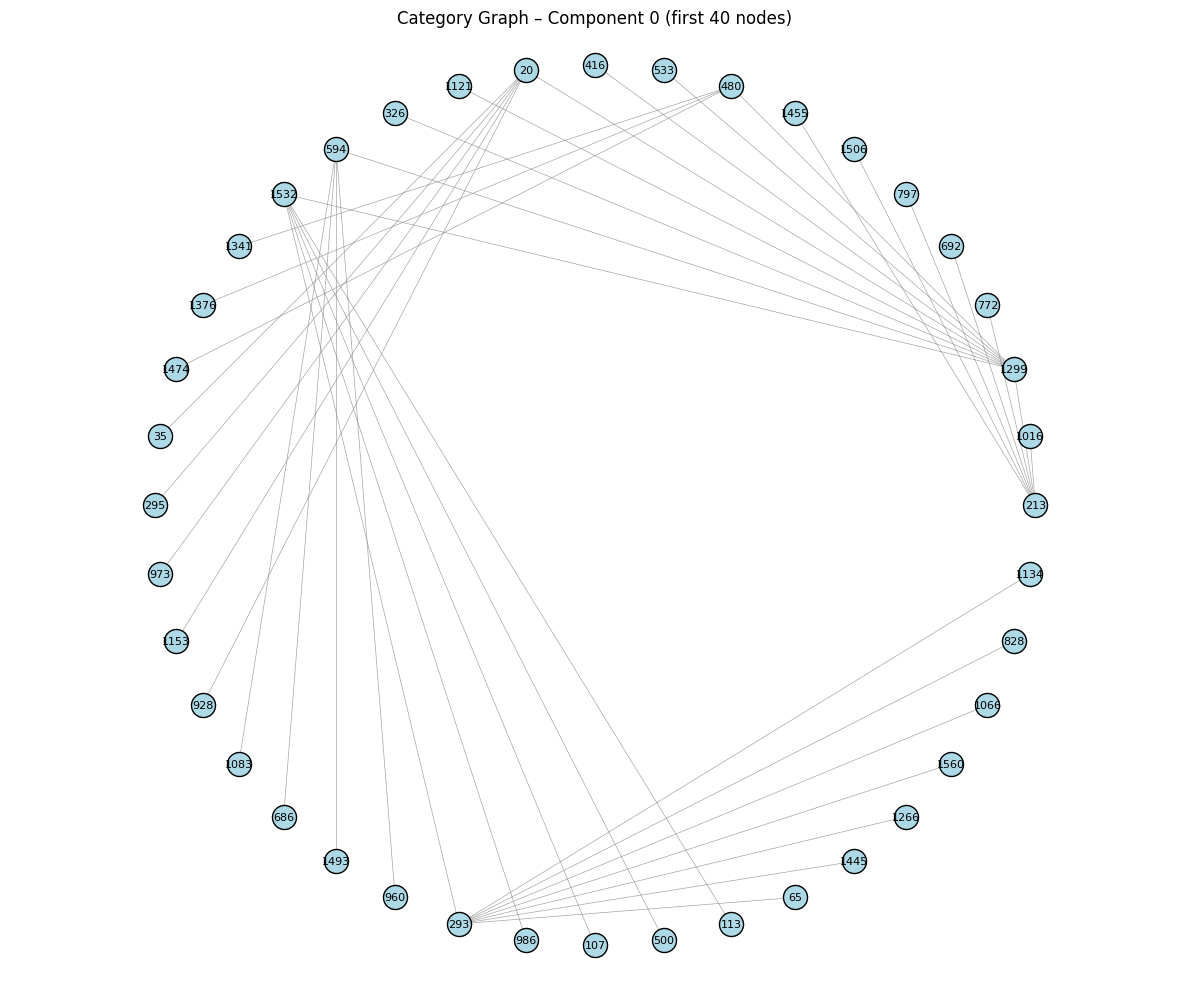

In [103]:
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import numpy as np

# Build graph: adjacency list (undirected)
graph = defaultdict(list)
parents = {}  # child -> parent

for _, row in cat_tree.iterrows():
    child = int(row['categoryid'])
    parent = row['parentid']
    if pd.notna(parent):
        parent = int(parent)
        graph[parent].append(child)
        graph[child].append(parent)   # undirected
        parents[child] = parent
    else:
        parents[child] = None

# Identify root categories (those with no parent)
root_categories = [node for node, p in parents.items() if p is None]
print("Root categories (first 10):", root_categories[:10])
print("Total nodes:", len(graph))

# Compute connected components (forest)
visited = set()
component_id = {}
comp_counter = 0
for node in graph:
    if node not in visited:
        queue = deque([node])
        visited.add(node)
        while queue:
            cur = queue.popleft()
            component_id[cur] = comp_counter
            for nb in graph[cur]:
                if nb not in visited:
                    visited.add(nb)
                    queue.append(nb)
        comp_counter += 1
print(f"Number of connected components: {comp_counter}")

# Function to draw a component (without networkx)
def draw_graph_component(component_idx=0, max_nodes=50):
    nodes_in_comp = [n for n, cid in component_id.items() if cid == component_idx]
    if len(nodes_in_comp) > max_nodes:
        nodes_in_comp = nodes_in_comp[:max_nodes]
    if not nodes_in_comp:
        print("No nodes in this component.")
        return
    node_to_idx = {node: i for i, node in enumerate(nodes_in_comp)}
    n = len(nodes_in_comp)
    adj = [[] for _ in range(n)]
    for node in nodes_in_comp:
        i = node_to_idx[node]
        for nb in graph[node]:
            if nb in node_to_idx:
                adj[i].append(node_to_idx[nb])
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = {i: (np.cos(angle), np.sin(angle)) for i, angle in enumerate(angles)}
    plt.figure(figsize=(12, 10))
    for i in range(n):
        for j in adj[i]:
            if i < j:
                x = [pos[i][0], pos[j][0]]
                y = [pos[i][1], pos[j][1]]
                plt.plot(x, y, 'gray', linewidth=0.5, alpha=0.7)
    for i in range(n):
        plt.scatter(pos[i][0], pos[i][1], s=300, c='lightblue', edgecolors='black', zorder=2)
        plt.text(pos[i][0], pos[i][1], str(nodes_in_comp[i]), ha='center', va='center', fontsize=8)
    plt.title(f"Category Graph – Component {component_idx} (first {n} nodes)")
    plt.axis('equal')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Draw the largest component (optional)
draw_graph_component(0, 40)

#### Section 4.3: Helper Functions for A*

In [104]:
# Improved item-category mapping: deterministic based on popularity rank
categories_list = list(graph.keys())
item_popularity = events['itemid'].value_counts()
item_rank = {item: rank for rank, item in enumerate(item_popularity.index)}
item_to_category = {}
for item in top_items:
    rank = item_rank.get(item, 0)
    cat_idx = rank % len(categories_list)
    item_to_category[item] = categories_list[cat_idx]

def get_item_category(item_id):
    return item_to_category.get(item_id, root_categories[0])

def compute_user_context(user_id, user_clusters, user_stats):
    """Build context vector for bandit: [cluster_onehot(4), log_user_events, log_recency, 0, 0]"""
    cluster_row = user_clusters[user_clusters['visitorid'] == user_id]
    cluster = int(cluster_row['cluster'].iloc[0]) if not cluster_row.empty else 0
    cluster_onehot = np.zeros(4)
    cluster_onehot[cluster] = 1
    if user_stats is not None:
        user_row = user_stats[user_stats['visitorid'] == user_id]
        if not user_row.empty:
            user_events = user_row['user_total_events'].iloc[0]
            recency = user_row['recency_days'].iloc[0]
        else:
            user_events = 1
            recency = 0
    else:
        user_events = 1
        recency = 0
    log_user_events = np.log1p(user_events)
    log_recency = np.log1p(recency)
    return np.concatenate([cluster_onehot, [log_user_events, log_recency, 0, 0]])

def get_purchase_probability(item_id, user_id, user_stats, item_stats, user_clusters, rf, scaler, kmeans):
    """Predict purchase probability using Random Forest."""
    # User features
    user_row = user_stats[user_stats['visitorid'] == user_id]
    if user_row.empty:
        u = [1, 1, 0, 0, 1, 0, 1, 1]
    else:
        u = [
            user_row['user_total_views'].iloc[0],
            user_row['user_total_events'].iloc[0],
            user_row['user_total_carts'].iloc[0],
            user_row['user_total_transactions'].iloc[0],
            user_row['user_activity_days'].iloc[0],
            user_row['recency_days'].iloc[0],
            user_row['num_sessions'].iloc[0] if 'num_sessions' in user_row.columns else 1,
            user_row['avg_items_per_session'].iloc[0] if 'avg_items_per_session' in user_row.columns else 1
        ]
    # Item features
    item_row = item_stats[item_stats['itemid'] == item_id]
    if item_row.empty:
        i = [1, 0, 0, 1000]
    else:
        i = [
            item_row['item_total_views'].iloc[0],
            item_row['item_total_carts'].iloc[0],
            item_row['item_total_transactions'].iloc[0],
            item_row['item_popularity_rank'].iloc[0]
        ]
    # Interaction features (not known at prediction time -> 0)
    interactions = [0, 0, 0]
    # Cluster
    cluster_row = user_clusters[user_clusters['visitorid'] == user_id]
    cluster = int(cluster_row['cluster'].iloc[0]) if not cluster_row.empty else 0
    
    features = u + i + interactions + [cluster]
    # Log transform skewed features (indices 0-7, 8-11, 12-14)
    log_indices = [0,1,2,3,4,5,6,7,8,9,10,12,13,14]
    for idx in log_indices:
        features[idx] = np.log1p(features[idx])
    features_scaled = scaler.transform([features])
    prob = rf.predict_proba(features_scaled)[0, 1]
    return prob

# Heuristic for A* (simplified – uses node index for demo)
def heuristic(node, goal, user_features=None):
    if node == goal:
        return 0.0
    prob = 0.5 + 0.01 * (node % 50) / 50.0
    return 1 - prob

#### Section 4.4: A* Search Algorithm Implementation

In [105]:
def a_star(start, goal, graph, heuristic_func, user_features=None):
    """
    A* search algorithm.
    Returns: (path, cost) where path is list of nodes from start to goal.
    """
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    g_score = {node: float('inf') for node in graph}
    g_score[start] = 0
    f_score = {node: float('inf') for node in graph}
    f_score[start] = heuristic_func(start, goal, user_features)

    while open_set:
        current_f, current = heapq.heappop(open_set)
        if current == goal:
            # Reconstruct path
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            return path, g_score[goal]

        for neighbor in graph[current]:
            # Cost = 1 per step (uniform)
            tentative_g = g_score[current] + 1
            if tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f = tentative_g + heuristic_func(neighbor, goal, user_features)
                f_score[neighbor] = f
                heapq.heappush(open_set, (f, neighbor))
    return None, float('inf')  # No path found

#### Section 4.5: Testing A* on Category Tree

In [106]:
# Find largest connected component
from collections import Counter
comp_sizes = Counter(component_id.values())
largest_comp = max(comp_sizes, key=comp_sizes.get)
print(f"Largest component ID: {largest_comp}, size: {comp_sizes[largest_comp]}")

nodes_in_largest = [node for node, cid in component_id.items() if cid == largest_comp]
if len(nodes_in_largest) >= 2:
    start_cat = nodes_in_largest[0]
    goal_cat = nodes_in_largest[-1]
    print(f"Finding path from category {start_cat} to {goal_cat} (within same component)...")
    path, cost = a_star(start_cat, goal_cat, graph, heuristic)
    if path:
        print(f"Path found with cost {cost}: {path}")
    else:
        print("No path found (unexpected within same component).")
else:
    print("Largest component has fewer than 2 nodes, cannot test.")

Largest component ID: 5, size: 290
Finding path from category 229 to 217 (within same component)...
Path found with cost 7: [229, 1028, 540, 140, 920, 1487, 908, 217]


#### Section 4.6: Integration with Recommendation System

In [107]:
# ==================== Use pre‑computed data from Notebook 3 if available ====================
print("Loading user/item stats from memory (Notebook 3) or creating minimal placeholders...")

# Try to get from memory (if kernel not restarted)
if 'user_stats' not in dir():
    print("Creating minimal placeholder user_stats (for demonstration only).")
    user_ids = events['visitorid'].unique()
    user_stats = pd.DataFrame({'visitorid': user_ids})
    user_stats['user_total_views'] = 1
    user_stats['user_total_events'] = 1
    user_stats['user_total_carts'] = 0
    user_stats['user_total_transactions'] = 0
    user_stats['user_activity_days'] = 1
    user_stats['recency_days'] = 0
    user_stats['num_sessions'] = 1
    user_stats['avg_items_per_session'] = 1
else:
    print("Using existing user_stats from memory.")

if 'item_stats' not in dir():
    print("Creating minimal placeholder item_stats.")
    item_ids = events['itemid'].unique()
    item_stats = pd.DataFrame({'itemid': item_ids})
    item_stats['item_total_views'] = 1
    item_stats['item_total_carts'] = 0
    item_stats['item_total_transactions'] = 0
    item_stats['item_popularity_rank'] = 1
else:
    print("Using existing item_stats from memory.")

# ==================== Make the category graph connected ====================
print("Making category graph connected by adding a super-root...")
# Find all original root categories (those with no parent)
original_roots = [node for node, p in parents.items() if p is None]
print(f"Original roots: {original_roots[:5]}... (total {len(original_roots)})")

# Add a super-root node (use a large number not in existing nodes)
super_root = max(graph.keys()) + 1 if graph else 1
graph[super_root] = []
for root in original_roots:
    graph[super_root].append(root)
    graph[root].append(super_root)
parents[super_root] = None

print(f"Graph now has {len(graph)} nodes and is connected via super-root {super_root}.")

# ==================== Precompute category -> items mapping ====================
category_to_items = defaultdict(list)
for item, cat in item_to_category.items():
    category_to_items[cat].append(item)

# ==================== Precompute popular items for fast RF arm ====================
popular_items = list(top_items[:100])

# ==================== Helper functions ====================
def get_user_feature_vector(user_id, user_stats, user_clusters):
    user_row = user_stats[user_stats['visitorid'] == user_id]
    if user_row.empty:
        u = [1, 1, 0, 0, 1, 0, 1, 1]
    else:
        u = [
            user_row['user_total_views'].iloc[0],
            user_row['user_total_events'].iloc[0],
            user_row['user_total_carts'].iloc[0],
            user_row['user_total_transactions'].iloc[0],
            user_row['user_activity_days'].iloc[0],
            user_row['recency_days'].iloc[0],
            user_row['num_sessions'].iloc[0],
            user_row['avg_items_per_session'].iloc[0]
        ]
    u_log = [np.log1p(x) for x in u]
    cluster_row = user_clusters[user_clusters['visitorid'] == user_id]
    cluster = int(cluster_row['cluster'].iloc[0]) if not cluster_row.empty else 0
    return u_log, cluster

def compute_user_context(user_id, user_clusters, user_stats):
    cluster_row = user_clusters[user_clusters['visitorid'] == user_id]
    cluster = int(cluster_row['cluster'].iloc[0]) if not cluster_row.empty else 0
    cluster_onehot = np.zeros(4)
    cluster_onehot[cluster] = 1
    if user_stats is not None:
        user_row = user_stats[user_stats['visitorid'] == user_id]
        if not user_row.empty:
            user_events = user_row['user_total_events'].iloc[0]
            recency = user_row['recency_days'].iloc[0]
        else:
            user_events = 1
            recency = 0
    else:
        user_events = 1
        recency = 0
    log_user_events = np.log1p(user_events)
    log_recency = np.log1p(recency)
    return np.concatenate([cluster_onehot, [log_user_events, log_recency, 0, 0]])

def recommend_for_user(user_id, target_item_id, bandit, knn, top_items, item_to_idx, item_user_sparse,
                       user_stats, user_clusters):
    target_cat = get_item_category(target_item_id)
    # Use super-root as start (ensures path always exists)
    start_cat = super_root
    path, _ = a_star(start_cat, target_cat, graph, heuristic)
    if not path:
        path = [target_cat]
    # Collect candidate items using precomputed mapping
    candidate_items = []
    for cat in path:
        candidate_items.extend(category_to_items.get(cat, []))
        if len(candidate_items) >= 50:
            candidate_items = candidate_items[:50]
            break
    if not candidate_items:
        candidate_items = list(top_items)[:20]
    context = compute_user_context(user_id, user_clusters, user_stats)
    arm = bandit.select_arm(context)
    if arm == 0:  # KNN
        if target_item_id in item_to_idx:
            idx = item_to_idx[target_item_id]
            distances, indices = knn.kneighbors(item_user_sparse[idx].reshape(1, -1))
            similar_indices = indices[0][1:6]
            rec_items = [list(top_items)[i] for i in similar_indices if i < len(top_items)]
        else:
            rec_items = candidate_items[:5]
    elif arm == 1:  # Random Forest (simplified: recommend top popular items)
        rec_items = popular_items[:5]
    else:  # Random
        rec_items = np.random.choice(candidate_items, size=min(5, len(candidate_items)), replace=False).tolist()
    return rec_items, arm, path, context

print("Section 4.6 ready – graph connected, stats ready.")

Loading user/item stats from memory (Notebook 3) or creating minimal placeholders...
Using existing user_stats from memory.
Using existing item_stats from memory.
Making category graph connected by adding a super-root...
Original roots: [231, 791, 1490, 431, 755]... (total 25)
Graph now has 1670 nodes and is connected via super-root 1699.
Section 4.6 ready – graph connected, stats ready.


#### Section 4.7: Evaluation of A* Performance

In [108]:
import time

def evaluate_a_star(num_tests=100):
    nodes = list(graph.keys())
    if len(nodes) < 2:
        print("Not enough nodes.")
        return
    total_time = 0
    total_cost = 0
    success = 0
    for _ in range(num_tests):
        start = np.random.choice(nodes)
        goal = np.random.choice(nodes)
        if start == goal:
            continue
        start_time = time.time()
        path, cost = a_star(start, goal, graph, heuristic)
        elapsed = time.time() - start_time
        if path:
            success += 1
            total_time += elapsed
            total_cost += cost
    if success > 0:
        print(f"Success rate: {success/num_tests:.2%}")
        print(f"Average time: {total_time/success:.6f} sec")
        print(f"Average path cost: {total_cost/success:.2f}")
    else:
        print("No successful paths found.")

evaluate_a_star(50)

Success rate: 100.00%
Average time: 0.003838 sec
Average path cost: 6.54


#### Section 4.8: Full Integration Example – End‑to‑End

In [109]:
def simulate_user_interaction(user_id, target_item, bandit, knn, top_items, item_to_idx, item_user_sparse,
                              user_stats, user_clusters):
    recs, arm, path, context = recommend_for_user(user_id, target_item, bandit, knn, top_items,
                                                  item_to_idx, item_user_sparse, user_stats, user_clusters)
    reward = 1 if np.random.rand() < 0.1 else 0
    bandit.update(arm, context, reward)
    return recs, arm, reward, path

# Reload bandit
with open(os.path.join(processed_path, 'linucb_bandit.pkl'), 'rb') as f:
    bandit_params = pickle.load(f)

class LinUCB:
    def __init__(self, n_arms, n_features, alpha=1.0):
        self.n_arms = n_arms
        self.alpha = alpha
        self.A = [np.identity(n_features) for _ in range(n_arms)]
        self.b = [np.zeros((n_features, 1)) for _ in range(n_arms)]
    def select_arm(self, context):
        context = context.reshape(-1, 1)
        p = np.zeros(self.n_arms)
        for arm in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[arm])
            theta = A_inv @ self.b[arm]
            mean = (theta.T @ context).item()
            uncertainty = self.alpha * np.sqrt((context.T @ A_inv @ context).item())
            p[arm] = mean + uncertainty
        return np.argmax(p)
    def update(self, chosen_arm, context, reward):
        context = context.reshape(-1, 1)
        self.A[chosen_arm] += context @ context.T
        self.b[chosen_arm] += reward * context

bandit = LinUCB(n_arms=3, n_features=8, alpha=1.0)
bandit.A = bandit_params['A']
bandit.b = bandit_params['b']
bandit.alpha = bandit_params['alpha']

# Use valid items (optional)
if 'nodes_in_largest' in locals():
    valid_categories = set(nodes_in_largest)
    valid_items = [item for item in top_items if get_item_category(item) in valid_categories]
else:
    valid_items = top_items
if not valid_items:
    valid_items = top_items

print("Running simulation for 10 users...")
for i in range(10):
    user = 1000 + i
    target = valid_items[i % len(valid_items)]
    recs, arm, reward, path = simulate_user_interaction(user, target, bandit, knn, top_items,
                                                        item_to_idx, item_user_sparse, user_stats, user_clusters)
    print(f"User {user}: target={target}, recs={recs[:3]}, arm={arm}, reward={reward}, path_len={len(path)}")

Running simulation for 10 users...
User 1000: target=84160, recs=[187946, 461686, 5411], arm=1, reward=0, path_len=5
User 1001: target=12217, recs=[322717, 416399, 338307], arm=0, reward=0, path_len=6
User 1002: target=133814, recs=[187946, 461686, 5411], arm=1, reward=0, path_len=4
User 1003: target=303828, recs=[285260, 123175, 232172], arm=2, reward=0, path_len=5
User 1004: target=394678, recs=[296989, 458271, 130221], arm=0, reward=0, path_len=4
User 1005: target=441852, recs=[187946, 461686, 5411], arm=1, reward=0, path_len=5
User 1006: target=241555, recs=[135446, 345576, 394678], arm=2, reward=0, path_len=5
User 1007: target=215715, recs=[79572, 425228, 380971], arm=0, reward=1, path_len=4
User 1008: target=62549, recs=[71733, 146613, 338395], arm=0, reward=1, path_len=5
User 1009: target=66752, recs=[403848, 267236, 334401], arm=0, reward=0, path_len=5


#### COMMENTS